In [44]:
# Libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import optuna
from sklearn.model_selection import cross_val_score

# For showing all the the Data Frame columns
%matplotlib inline
pd.set_option('display.max_columns', None) 

In [45]:
from utils import *

In [46]:
# importing reduced dataset
df = pd.read_csv('../data/workable_data.csv')

In [47]:
df.head()

,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,Pressure_switch,Oil_level,Caudal_impulses,day,month,hour,minute,second,failure
0,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1,2,0,0,0,0
1,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1,2,0,0,10,0
2,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1,2,0,0,19,0
3,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1,2,0,0,29,0
4,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1,2,0,0,39,0


In [48]:
# Select target and features
X = df.drop('failure', axis=1)
y = df['failure']

In [49]:
# Split the data in a way that the test data contains 1 of the failures and the train 3 of the failures
split_index = int(len(df) * 0.7)
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [50]:
# SMOTE with sampling_strategy = 0.05 
smote = SMOTE(sampling_strategy=0.05, random_state=42) 
X_train, y_train = smote.fit_resample(X_train, y_train)

In [51]:
# Fit the model
rf = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Feature importance

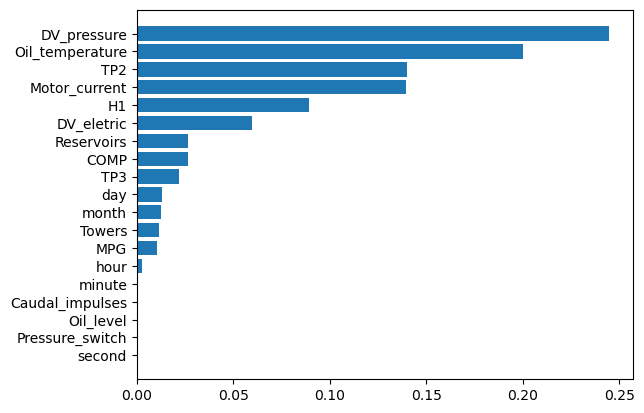

In [52]:
sort_idx = rf.feature_importances_.argsort()
plt.barh(X.columns[sort_idx], rf.feature_importances_[sort_idx])
plt.show();

## First Drop

In [ ]:
X = X.drop(['second', 'Pressure_switch', 'Oil_level', 'Caudal_impulses', 'minute', 'hour', 'MPG', 'COMP'], axis=1)

In [ ]:
corr = np.abs(X.corr())

# Set up mask for triangle representation
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(16, 16))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap
sns.heatmap(corr, mask=mask, vmax=1, square=True, 
            linewidths=.5, cbar_kws={"shrink": .5},
            annot=True, fmt='.2f',   # fmt='.2f' to round to 2 decimals
            cmap='rocket', ax=ax)

plt.title('Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Split the data in a way that the test data contains 1 of the failures and the train 3 of the failures
split_index = int(len(df) * 0.7)
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [ ]:
# SMOTE with sampling_strategy = 0.05 
smote = SMOTE(sampling_strategy=0.05, random_state=42) 
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
# Fit the model
rf = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

In [ ]:
results = evaluate_model(
    rf,
    X_train, X_test,
    y_train, y_test,
    'Droping_columns',
    'chronological split + SMOTE sampling_strategy=0.0.5 + threshold=0.15',
    threshold=0.15
)

In [ ]:
results

### Conclution
I chose to drop the columns: 'second', 'Pressure_switch', 'Oil_level', 'Caudal_impulses', 'minute', 'hour', 'MPG', 'COMP'

# Hyperparameter Optimization with Time-Series Cross-Validation

In [167]:
df_s = pd.read_csv('../data/reduced_data.csv')

In [152]:
df_s.columns

Index(['timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs',
       'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers',
       'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses',
       'failure', 'month', 'day', 'hour', 'minute'],
      dtype='object')

In [168]:
df_s = df_s.drop(['timestamp', 'LPS', 'Pressure_switch', 'Oil_level', 
                  'Caudal_impulses', 'minute', 'hour', 'MPG', 'COMP'], axis=1).reset_index(drop=True)

In [113]:
df_s.head()

,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,DV_eletric,Towers,failure,month,day
0,-0.012286,9.327429,9.311143,-0.022857,9.328000,53.521427,0.040357,False,True,False,2,1
1,-0.013000,9.260000,9.243333,-0.023333,9.259666,53.420834,0.040000,False,True,False,2,1
2,-0.012667,9.198334,9.182000,-0.022333,9.199000,53.325000,0.040000,False,True,False,2,1
3,-0.012333,9.136666,9.120667,-0.022667,9.136666,53.200000,0.040000,False,True,False,2,1
4,-0.013000,9.075666,9.060000,-0.023000,9.075666,53.129166,0.040000,False,True,False,2,1


In [154]:
df_s.isna().sum()

TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Motor_current      0
DV_eletric         0
Towers             0
failure            0
month              0
day                0
dtype: int64

In [169]:
# Select target and features
X = df_s.drop('failure', axis=1)
y = df_s['failure'].astype(int)

In [116]:
y.dtype

dtype('int64')

In [170]:
# Split the data in a way that the test data contains 1 of the failures and the train 3 of the failures
split_index = int(len(df_s) * 0.7)
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [145]:
# make sure test data contain failure values
print(y_test.unique())
X_test.head()

[0 1]


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,DV_eletric,Towers,month,day
176904,-0.011667,8.917334,8.905666,-0.018000,8.920333,66.016670,0.040417,False,True,6,29
176905,-0.012000,8.750000,8.739333,-0.018333,8.753000,64.762500,0.040417,False,True,6,29
176906,-0.013000,8.628000,8.617333,-0.018667,8.630667,64.245834,0.038750,False,True,6,29
176907,-0.013000,8.527667,8.516334,-0.018333,8.529000,63.570835,0.039583,False,True,6,29
176908,-0.012667,8.439667,8.428333,-0.018667,8.441000,62.841667,0.040000,False,True,6,29


In [ ]:
# from sklearn.metrics import make_scorer, recall_score
# # Define parameter distribution for sampling
# param_dist = {
#     'n_estimators': [100, 200, 300, 500],   # number of trees
#     'max_depth': [None, 10, 20, 30],        # tree depth
#     'min_samples_split': [2, 5, 10],        # min samples to split
#     'min_samples_leaf': [1, 2, 4],          # min samples per leaf
#     'max_features': ['sqrt', 'log2', None]  # number of features per split
# }

# # Create the scorer object
# recall_class1 = make_scorer(recall_score, pos_label=True)
# # Randomized search
# random_search = RandomizedSearchCV(
#     estimator=RandomForestClassifier(
#         class_weight='balanced',
#         random_state=42,
#         n_jobs=-1),
#     param_distributions=param_dist,
#     n_iter=20,                 # number of random combinations to try
#     cv=3,                      # 3-fold cross-validation (faster than 5)
#     scoring=recall_class1,
#     n_jobs=-1,                 # use all CPU cores
#     verbose=2,
#     random_state=42
# )
# # Fit randomized search
# random_search.fit(X_train, y_train)

# # Best parameters
# print("Best parameters:", random_search.best_params_)

# # Best model
# best_rf = random_search.best_estimator_

In [ ]:
# # Evaluate on test set
# y_prob = best_rf.predict_proba(X_test)[:, 1]
# y_pred = (y_prob >= 0.15).astype(int)

# print(classification_report(y_test, y_pred, zero_division=0))

In [173]:
def objective(trial):
    # 1. Search Space (Balanced for F2)
    sampling_strat = trial.suggest_float('sampling_strategy', 0.1, 0.6)
    
    rf_params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 400),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 10),
        'class_weight': 'balanced', 
        'n_jobs': -1,
        'random_state': 42
    }
    
    threshold = trial.suggest_float('threshold', 0.05, 0.35)

    tscv = TimeSeriesSplit(n_splits=3)
    scores = []

    for train_idx, val_idx in tscv.split(X_train):
        X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # --- THE CRITICAL FIX ---
        # We check both training AND validation for at least one failure (Class 1)
        if y_t.sum() == 0 or y_v.sum() == 0:
            continue 

        model = Pipeline([
            ('smote', SMOTE(sampling_strategy=sampling_strat, random_state=42)),
            ('rf', RandomForestClassifier(**rf_params))
        ])

        # If it gets here, we are GUARANTEED to have both classes
        model.fit(X_t, y_t)
        
        y_prob = model.predict_proba(X_v)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        # F2-Score: Better balance between Recall and Precision
        val_score = fbeta_score(y_v, y_pred, beta=2, pos_label=1, zero_division=0)
        scores.append(val_score)

    # Return 0.0 if no folds were valid, otherwise the average
    return np.mean(scores) if len(scores) > 0 else 0.0

In [174]:
# 1. Run the study with a timeout or trial limit
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=400, show_progress_bar=True)

# 2. Extract ALL hyperparameters
best_params = study.best_params
print("Found the best configuration:", best_params)

# 3. Separate the 'Meta-Parameters' from the 'Model-Parameters'
# We pop them out of the dictionary so we can pass the rest to RandomForest
best_threshold = best_params.pop('threshold')
best_sampling_strat = best_params.pop('sampling_strategy')

Best trial: 248. Best value: 0.985726: 100%|██████████| 400/400 [22:28<00:00,  3.37s/it]

Found the best configuration: {'sampling_strategy': 0.438531449909431, 'n_estimators': 358, 'max_depth': 6, 'min_samples_leaf': 2, 'threshold': 0.06007117738035486}


{'sampling_strategy': 0.438531449909431, 'n_estimators': 358, 'max_depth': 6, 'min_samples_leaf': 2, 'threshold': 0.06007117738035486}

In [175]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

final_model = Pipeline([
    ('smote', SMOTE(sampling_strategy=best_sampling_strat, random_state=42)),
    ('rf', RandomForestClassifier(**best_params, n_jobs=-1, random_state=42))
])
final_model.fit(X_train, y_train)

,steps,"[('smote', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,0.438531449909431
,random_state,42
,k_neighbors,5
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",358
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [176]:
y_probs = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= best_threshold).astype(int)

In [177]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     75546
           1       0.22      0.71      0.33       270

    accuracy                           0.99     75816
   macro avg       0.61      0.85      0.66     75816
weighted avg       1.00      0.99      0.99     75816



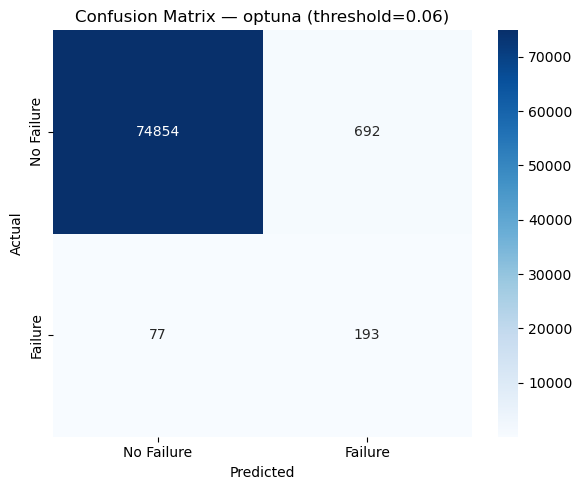

In [180]:
results = evaluate_model(
    final_model,
    X_train, 
    X_test,    
    y_train, 
    y_test,
    'optuna',
    'chronological split + smote sampling strategy 0.43 + threshold 0.6',
    threshold=0.06
)